# STAT 207 Project 03 - Linear Regression Analysis of Spotify Chart Data

Jadyn, Elisha, Kelly

<hr>

## 1. Introduction

In [ ]:
#imports

import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mean_squared_error


#### **Dataset Introduction**: This datatset contains audio characteristics of the top 2000 Spotify songs from 2000-2019. Throughout the 18 columns, things like danceability, genre, and tempo are recorded. Each row represents 1 song and we are also given the name of the artists and how popular it was.

#### **Research Questions**: My first question for linear regression is, "What is the relationship between a song's danceability and its popularity, after controlling for energy, loudness, tempo, and acousticness, both in the sample and in the underlying population? How well does this model predict popularity on new data?" My second question for logistic regression is, "How do energy, loudness, and tempo relate to the log-odds of a song being explicit in the training data? How does a classifier built on this model perform on new data?"

#### **Response Variables**: For my first question concerning my linear regression model, my response variable is Popularity (a quantitative variable measured on a 0–100 scale). As for my second question concerning the logistic regression model, my response variable is Explicit (a logical variable (True/False) indicating whether a song contains explicit content). 

#### **Contextual Importance**: If someone is trying to increase their odds of making a very popular songs, they may want to look at previously successful songs and try to determine if there are any patterns that could be incorporated into a songs to increase its likelihood of being a hit. Additionally, it could be useful to understand what variables or characteristics are associated with explicit content since that could be useful for music platforms or radio stations that mainly appeal to younger audiences and need to censor their music.

## 2. Linear Regression Analytical Tasks

### **Research Question**: What is the relationship between a song's danceability and its popularity, after controlling for energy, loudness, tempo, and acousticness, both in the sample and in the underlying population? How well does this model predict popularity on new data?

In [14]:
df = pd.read_csv("songs_normalize.csv")
df

,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
0,Britney Spears,Oops!...I Did It Again,211160,False,2000,77,0.751,0.834,1,-5.444,0,0.0437,0.3000,0.000018,0.3550,0.894,95.053,pop
1,blink-182,All The Small Things,167066,False,1999,79,0.434,0.897,0,-4.918,1,0.0488,0.0103,0.000000,0.6120,0.684,148.726,"rock, pop"
2,Faith Hill,Breathe,250546,False,1999,66,0.529,0.496,7,-9.007,1,0.0290,0.1730,0.000000,0.2510,0.278,136.859,"pop, country"
3,Bon Jovi,It's My Life,224493,False,2000,78,0.551,0.913,0,-4.063,0,0.0466,0.0263,0.000013,0.3470,0.544,119.992,"rock, metal"
4,*NSYNC,Bye Bye Bye,200560,False,2000,65,0.614,0.928,8,-4.806,0,0.0516,0.0408,0.001040,0.0845,0.879,172.656,pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,Jonas Brothers,Sucker,181026,False,2019,79,0.842,0.734,1,-5.065,0,0.0588,0.0427,0.000000,0.1060,0.952,137.958,pop
1996,Taylor Swift,Cruel Summer,178426,False,2019,78,0.552,0.702,9,-5.707,1,0.1570,0.1170,0.000021,0.1050,0.564,169.994,pop
1997,Blanco Brown,The Git Up,200593,False,2019,69,0.847,0.678,9,-8.635,1,0.1090,0.0669,0.000000,0.2740,0.811,97.984,"hip hop, country"
1998,Sam Smith,Dancing With A Stranger (with Normani),171029,False,2019,75,0.741,0.520,8,-7.513,1,0.0656,0.4500,0.000002,0.2220,0.347,102.998,pop


#### **Train Test Split**

In [15]:
train, test = train_test_split(df, test_size=0.2, random_state=313)

#### **Fitting Linear Regression Model**

In [16]:
model = smf.ols('popularity ~ danceability + energy + loudness + tempo + acousticness', data=train).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             popularity   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.485
Date:                Thu, 30 Apr 2026   Prob (F-statistic):              0.191
Time:                        21:11:26   Log-Likelihood:                -7178.4
No. Observations:                1600   AIC:                         1.437e+04
Df Residuals:                    1594   BIC:                         1.440e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       67.6878      6.638     10.197      0.000      54.668      80.708
danceability    -1.5135      3.930     -0.385      0.700      -9.222       6.195
energy          -7.8361      4.995     -1.569      0.117     -17.633       1.961
loudness         0.8319      0.374      2.227      0.026       0.099       1.565
tempo            0.0233      0.020      1.141      0.254      -0.017       0.063
acousticness     2.9646      3.506      0.845      0.398      -3.913       9.842
==============================================================================
Omnibus:                      525.300   Durbin-Watson:                   1.941
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1302.175
Skew:                          -1.807   Prob(JB):                    1.72e-283
Kurtosis:                       5.544   Cond. No.                     1.87e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.87e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### **Linear Regression Equation:** popularity(hat) = 67.6878 + danceability(-1.5135) + energy(-7.8361) + loudness(0.8319) + tempo(0.0233) + acousticness(2.9646)

#### **Slope Coefficient Interpretation:** For every unit that danceability increases, the average estimated popularity of a song will decrease by 1.5135 units, holding loudness, tempo, and acoutsticness constant.

#### **95% Confidence Interval:** We are 95% confident that the true population slope for how much danceability impacts popularity , on average, for every 1 unit increased of danceability, falls in the range (-8.386, 6.914), holding loudness, tempo, and acoutsticness constant.

#### **Linear Regression Conditions: Fitted vs Residual Plot, QQ Plot**

In [17]:
fitted = model.fittedvalues

residuals = model.resid

Text(0, 0.5, 'Residuals')

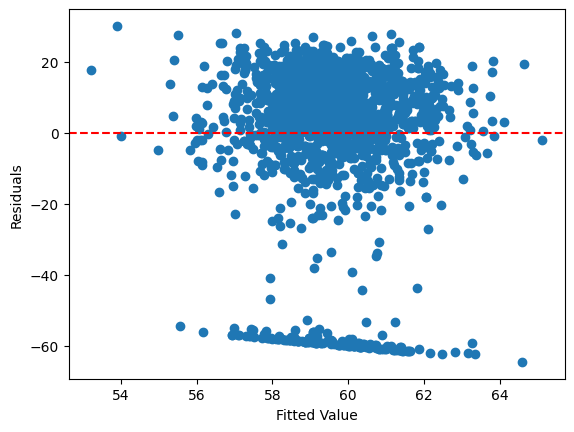

In [18]:
plt.scatter(fitted, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Value')
plt.ylabel('Residuals')

Text(0.5, 1.0, 'Normal Q-Q Plot of Residuals')

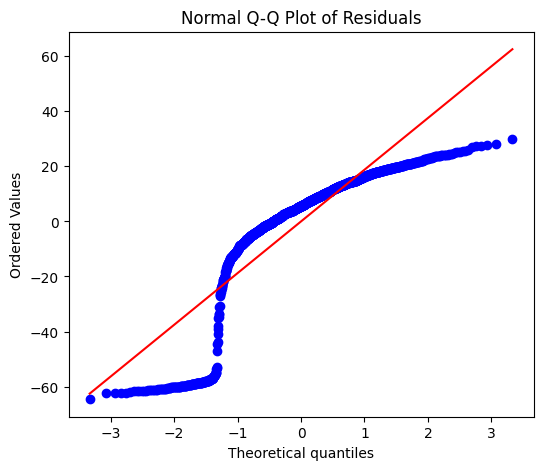

In [ ]:
sm.qqplot(residuals)

#### **Fitted vs Residuals Plot:** The residuals vs fitted plot seems to show two clusters of residuals with a very large group centered near 0 and another smaller group nearing around -60. This shows that the linearity and equal variance conditions are not met at all. We want residuals to be randomly scattered around 0 with no pattern whereas our graph clearly shows clusters. 

#### **QQ Plot:** The QQ plot shows that the residuals do not follow the diagonal line at all, making almost of a curved shape and we can also see points dropping t around -60 instead of following the expected normal distribution. The two ends don't follow the line well so we can see that the normality condition is NOT met at all. 


#### **Model Performance:** Our R^2 value is .003. This means .3% of the variability in our data can be explained by the model. This is VERY low, indicating our model is likely not a good fit. The RMSE on the test data is about 20.493, which is again VERY low. This means that on average, our model's predictions of song popularity are off by about 20.493 points. This suggests our model does not predict popularity on new songs very well.

In [27]:
test_preds_linear = model.predict(test)
rmse = np.sqrt(mean_squared_error(test['popularity'], test_preds_linear))
rmse

np.float64(20.493363413600754)

## 3. Logistic Regression Analytical Tasks

### **Research Question**: How do energy, loudness, and tempo relate to the log-odds of a song being explicit in the training data? How well does a classifier built on this model perform on new data?

In [21]:
train["new_explicit"] = 1 * (train["explicit"] == True)
train

,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre,new_explicit
654,Fall Out Boy,"Dance, Dance",180266,False,2005,74,0.622,0.961,11,-3.198,0,0.1540,0.005230,0.000000,0.0854,0.449,114.452,rock,0
1716,Rae Sremmurd,Swang,208120,True,2016,75,0.681,0.314,8,-9.319,1,0.0581,0.200000,0.000010,0.1000,0.166,139.992,"hip hop, pop",1
641,P!nk,Stupid Girls,197173,True,2006,0,0.683,0.886,4,-5.045,0,0.0710,0.000738,0.001880,0.0524,0.566,100.040,pop,1
463,G-Unit,Wanna Get To Know You,265026,True,2003,61,0.513,0.826,10,-3.651,0,0.1320,0.106000,0.000000,0.0675,0.889,76.910,"hip hop, pop",1
557,Natalie Imbruglia,Shiver,222653,False,2005,52,0.489,0.798,1,-4.490,1,0.0316,0.001150,0.000003,0.1490,0.309,94.163,"pop, Folk/Acoustic",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39,Avant,Separated,255600,False,2000,55,0.798,0.480,0,-5.564,1,0.0276,0.247000,0.000000,0.2370,0.643,108.241,"pop, R&B",0
1055,Cali Swag District,Teach Me How to Dougie,237480,True,2011,66,0.846,0.438,11,-4.981,1,0.1410,0.200000,0.000094,0.0939,0.512,85.013,"hip hop, pop",1
983,The Fray,Never Say Never,256613,False,2009,67,0.230,0.492,8,-5.767,1,0.0317,0.568000,0.000008,0.1760,0.262,160.139,pop,0
426,LL Cool J,Headsprung,267320,False,2004,56,0.718,0.786,0,-5.760,1,0.0284,0.011400,0.000025,0.0745,0.465,99.916,"hip hop, pop, R&B",0


#### **Logistic Regression Model:**


In [22]:
log_model = smf.logit('new_explicit ~ energy + loudness + tempo', data=train).fit()

log_model.summary()

Optimization terminated successfully.
         Current function value: 0.570684
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           new_explicit   No. Observations:                 1600
Model:                          Logit   Df Residuals:                     1596
Method:                           MLE   Df Model:                            3
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                 0.02670
Time:                        21:11:26   Log-Likelihood:                -913.09
converged:                       True   LL-Null:                       -938.15
Covariance Type:            nonrobust   LLR p-value:                 7.585e-11
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7283      0.561      1.298      0.194      -0.371       1.828
energy        -2.8614      0.497     -5.762      0.000      -3.835      -1.888
loudness       0.0327      0.039      0.834      0.404      -0.044       0.109
tempo          0.0042      0.002      1.995      0.046    7.34e-05       0.008
==============================================================================
"""

#### **Explanatory Variable Characteristics:** Looking at our three explanatory variables that we chose, lower energy is associated with a higher probability of a song being explicit as we can see the coefficient for energy is -2.8614. For loudness, we can see that our coefficient is positive, 0.0327 so this indicates that higher loudness values are associated with a higher probability of being explicit due to the positive coefficient. Lastly, higher tempo is associated with a higher probability of being explicit due to the fact the coefficient is positive as its 0.0042. 

In [23]:
train_probs = log_model.predict(train)
auc = roc_auc_score(train['explicit'], train_probs)
auc

0.619991696689104

#### **Pseudo-R2 and AUC:** Our Pseudo R^2 value is 0.0267. Once again this is VERY low, indicating our model is not very accurate and also indicates that very little of the variability in whether a song is explicit is explained by our model. Our AUC value is around 0.62, and again this is VERY low and shows us that our model is pretty weak at classifying explicit songs.


#### **Classifer:**


In [24]:
test_probs = log_model.predict(test)

test_preds = (test_probs >= 0.5).astype(int)

#### **Accuracy Rate, Sensitivity, and Specificity:**

In [25]:
from sklearn.metrics import confusion_matrix

confusmatrix = confusion_matrix(test['explicit'], test_preds)
confusmatrix


accuracy = (1 + 282) / (282 + 4 + 113 + 1)
sensitivity = 1 / (1 + 113)
specificity = 282 / (282 + 4)

print(accuracy, sensitivity, specificity)

0.7075 0.008771929824561403 0.986013986013986


#### **Error to Minimize:** The type of error we want to minimize is a false negative. For a example if a song was predicted to be not explicit, and a radio host decides to play it. It will be very bad for a family freindly radio channel if the song actually was explicit. That's why it's worse for this model to predict a false negative rather than a false positive for a song being explicit. 

#### **Performance of Classifer:** We are not satisfied with the performance of our classifier. Even though our accuracy is about 70% and we have a specificty of 98.6%, the sensitivity of 0.88% shows that our model doesn't correctly identify many of the truly explicit songs. We want to minimize false negatives so this performance is pretty bad and poor. In the context of our radio host example we showed earlier, this means nearly every explicit song would be incorrectly cleared as safe to play, which defeats the entire purpose of the classifier.


## Any other type of analysis/question you want to explore with this dataset.

<u>Why?</u>: Sometimes undergraduate students will put the research projects that they did for their classes on their resumes when applying for graduate schools, internships, and jobs. If you're interested in showcasing cool analyses to write on your resume, this section could help with that. **(This section is not worth any points though).**

## 4. Conclusion

### **Summarization**:  In this project, we fit a linear regression model to predict song popularity using danceability, energy, loudness, tempo and acousticness and then also fit a logistic regression model to predict whether a song is explicit using energy, loudness, and tempo. Both models performed pretty poorly and not as well as we wanted as we saw a very low R squared value and a high RMSE value for our linear model and a low AUC value for the logistic model. Our classifer also had an extremely low sensitivity value. 


### **Limitations**: This dataset is a relatively small one compared to all songs that have been released, and additionally they all have high popularity because it is a compilation of the top most popular Spotify songs from 2000-2019, so having a baseline of high popularity might be making our analysis more difficult. Additionally, any findings from this data cannot be generalized to all songs because it is only recording songs from Spotify, however, there are other mdoes of listening to music such as Apple Music, the radio, and vinyls, which are harder to collect data on. We don't want to extrapolate any of our findings beyond the reach of our dataset, so this would be something to keep in mind for future analysis. 

### **Future Work**:  In the future, we might want to do forward or backward selection to see if there are any variables that would better help us predict our response variables. We could also try to cross reference with other data to see if other variables besides just the ones listed in this one have an impact on the popularity or explicity of songs. 